# SOB4ES - Red Neuronal con Pérdida Personalizada

### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluación de los modelos

Este notebook extiende el MLP multisalida estándar con una **función de pérdida personalizada** que penaliza las predicciones que no respetan la estructura de correlación entre targets observada en los datos de entrenamiento.

La pérdida tiene dos componentes:
- **MSE estándar:** minimiza el error de predicción por target individualmente.
- **Penalización de correlación:** compara la matriz de correlación de las predicciones con la matriz de correlación de los targets reales en el batch.
	Si el modelo predice valores que rompen las correlaciones biológicas conocidas (por ejemplo, diversidad alta de lombrices con diversidad muy baja de colémbolos cuando normalmente co-varian), la pérdida aumenta.

El peso relativo entre ambos componentes se controla con el parámetro `lambda_corr`.

  **Datasets utilizados:**
- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por país)
- `test.csv` - Búsqueda de hiperparámetros y validación cruzada (15 %)
- `eval.csv` - Evaluación final e imparcial del rendimiento (15 %)


**Estructura del notebook:**
1. **Configuración:** importaciones y parámetros globales.
2. **Carga de datos:** se cargan los tres splits pre-generados.
3. **Definicion de la perdida personalizada y tuning.**
4. **Validación cruzada:** evaluación de robustez.
5. **Analisis de pesos e importancia de variables.**
6. **Producción:** entrenamiento final y exportación de modelos.
7. **Evaluación final:** rendimiento real sobre `eval.csv`.

## 1.- Configuración del entorno

En esta sección del notebook importaremos todas las librerías necesarias como también realizaremos las configuraciones iniciales.

In [1]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
import itertools
from pathlib import Path
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings('ignore')

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/mlp_custom/'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo de computo: {DEVICE}')

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]

print('Librerias y variables cargadas correctamente...')


# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}

# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)

Dispositivo de computo: cuda
Librerias y variables cargadas correctamente...


In [2]:
# Ajuste automatico de n_jobs segun los nucleos disponibles
# Evita saturar la maquina (todos los procesos a la vez con n_jobs=-1)
import os

def get_n_jobs(fraccion=0.75, reserva=1):
    """Calcula un n_jobs seguro dejando al menos `reserva` nucleos libres
    para que el sistema no se vuelva inutilizable durante la ejecucion."""
    n_cpu = os.cpu_count() or 1
    n_usar = max(1, min(int(n_cpu * fraccion), n_cpu - reserva))
    return n_usar

N_JOBS = get_n_jobs()
print(f'Nucleos disponibles: {os.cpu_count()} | n_jobs asignado: {N_JOBS}')

Nucleos disponibles: 16 | n_jobs asignado: 12


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la división 70/15/15 estratificada por país.

| Archivo     | Uso                                      | Filas aprox. |
| ----------- | ---------------------------------------- | ------------ |
| `train.csv` | Ajuste del modelo                        | 299          |
| `test.csv`  | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv`  | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la sección 7 para garantizar una estimación imparcial del rendimiento.

In [3]:
def cargar_csv(ruta, nombre):
    if not os.path.exists(ruta):
        raise FileNotFoundError(f'No se encontro: {ruta}')
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f'  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas')
    return df

print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados...")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}  |  y_eval: {y_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados...
X_train: (299, 34)  |  X_test: (64, 34)  |  X_eval: (65, 34)
y_train: (299, 21)  |  y_test: (64, 21)  |  y_eval: (65, 21)


## 3.- Pérdida personalizada y tuning
### Función de pérdida

La pérdida combina dos terminos:

```

Loss = MSE(y_pred, y_real) + lambda_corr * CorrelationPenalty(y_pred, y_real)

```

La penalización de correlación se calcula como la **diferencia de Frobenius** entre la matriz de correlación de las predicciones y la de los valores reales en cada batch:

```

CorrelationPenalty = || corr(y_pred) - corr(y_real) ||_F

```

Un `lambda_corr` alto fuerza al modelo a respetar las correlaciones biológicas pero puede perjudicar la precisión individual por target. El tuning busca el valor óptimo de este parámetro junto a la arquitectura.

### Arquitectura

Idéntica al MLP estándar: capas densas con ReLU, Dropout y capa de salida lineal de 21 neuronas.

In [4]:
class MLPMultiSalida(nn.Module):
    def __init__(self, n_inputs, n_outputs, hidden_sizes, dropout_rate):
        super().__init__()
        layers = []
        in_size = n_inputs
        for h in hidden_sizes:
            layers += [nn.Linear(in_size, h), nn.ReLU(), nn.Dropout(dropout_rate)]
            in_size = h
        layers.append(nn.Linear(in_size, n_outputs))
        self.red = nn.Sequential(*layers)
    def forward(self, x):
        return self.red(x)


def correlation_matrix(y):
    """
    Calcula la matriz de correlacion de un tensor (batch x targets).
    Se usa para comparar las correlaciones entre targets predichos vs reales.
    """
    y_centered = y - y.mean(dim=0, keepdim=True)
    std = y_centered.std(dim=0, keepdim=True).clamp(min=1e-8)
    y_norm = y_centered / std
    return torch.mm(y_norm.T, y_norm) / y.shape[0]


class CorrelationAwareLoss(nn.Module):
    """
    Perdida personalizada que combina MSE con una penalizacion
    por diferencias en la estructura de correlacion entre targets.
    lambda_corr controla el peso de la penalizacion:
      - lambda_corr = 0.0: equivale a MSE puro
      - lambda_corr = 1.0: penalizacion de correlacion con mismo peso que MSE
    """
    def __init__(self, lambda_corr=0.1):
        super().__init__()
        self.lambda_corr = lambda_corr
        self.mse = nn.MSELoss()

    def forward(self, y_pred, y_real):
        mse_loss  = self.mse(y_pred, y_real)
        corr_pred = correlation_matrix(y_pred)
        corr_real = correlation_matrix(y_real)
        # Norma de Frobenius: penaliza diferencias elemento a elemento entre matrices
        corr_loss = torch.norm(corr_pred - corr_real, p='fro')
        return mse_loss + self.lambda_corr * corr_loss


def entrenar_mlp_custom(X_tr, y_tr, X_val, y_val, hidden_sizes, dropout, lr, epochs, batch_size, lambda_corr):
    X_t = torch.tensor(X_tr.values, dtype=torch.float32).to(DEVICE)
    y_t = torch.tensor(y_tr.values, dtype=torch.float32).to(DEVICE)
    X_v = torch.tensor(X_val.values, dtype=torch.float32).to(DEVICE)
    y_v = torch.tensor(y_val.values, dtype=torch.float32).to(DEVICE)

    loader    = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)
    model     = MLPMultiSalida(X_tr.shape[1], y_tr.shape[1], hidden_sizes, dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = CorrelationAwareLoss(lambda_corr=lambda_corr)

    model.train()
    for epoch in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred = model(X_v).cpu().numpy()
    r2 = r2_score(y_val.values, y_pred, multioutput='uniform_average')
    return model, r2


# Grid de hiperparametros: arquitectura + lambda_corr
grid = [
    {'hidden': [32, 16], 'dropout': 0.2, 'lr': 1e-3, 'epochs': 150, 'batch': 16, 'weight_decay': 1e-2, 'lambda_corr': 0.0},
    {'hidden': [64, 32], 'dropout': 0.2, 'lr': 1e-3, 'epochs': 150, 'batch': 16, 'weight_decay': 1e-2, 'lambda_corr': 0.0},
    {'hidden': [64, 32], 'dropout': 0.2, 'lr': 1e-3, 'epochs': 150, 'batch': 16, 'weight_decay': 5e-3, 'lambda_corr': 0.05},
    {'hidden': [64, 32], 'dropout': 0.3, 'lr': 1e-3, 'epochs': 200, 'batch': 32, 'weight_decay': 5e-3, 'lambda_corr': 0.1},
    {'hidden': [128, 64], 'dropout': 0.3, 'lr': 1e-3, 'epochs': 200, 'batch': 32, 'weight_decay': 2e-3, 'lambda_corr': 0.05},
    {'hidden': [128, 64], 'dropout': 0.3, 'lr': 1e-3, 'epochs': 200, 'batch': 32, 'weight_decay': 2e-3, 'lambda_corr': 0.2},
    {'hidden': [128, 32], 'dropout': 0.3, 'lr': 5e-4, 'epochs': 250, 'batch': 16, 'weight_decay': 1e-3, 'lambda_corr': 0.1},
    {'hidden': [128, 32], 'dropout': 0.4, 'lr': 5e-4, 'epochs': 250, 'batch': 16, 'weight_decay': 2e-3, 'lambda_corr': 0.3},
    {'hidden': [64, 16, 8], 'dropout': 0.2, 'lr': 1e-3, 'epochs': 200, 'batch': 16, 'weight_decay': 1e-3, 'lambda_corr': 0.1},
    {'hidden': [64, 16, 8], 'dropout': 0.3, 'lr': 1e-3, 'epochs': 200, 'batch': 16, 'weight_decay': 5e-3, 'lambda_corr': 0.5},
    {'hidden': [128, 64, 32], 'dropout': 0.4, 'lr': 5e-4, 'epochs': 200, 'batch': 32, 'weight_decay': 5e-3, 'lambda_corr': 0.2}
]

print('Buscando mejor configuracion (arquitectura + lambda_corr)...\n')
mejor_r2     = -np.inf
mejor_config = None

for cfg in grid:
    _, r2 = entrenar_mlp_custom(
        X_train, y_train, X_test, y_test,
        cfg['hidden'], cfg['dropout'], cfg['lr'],
        cfg['epochs'], cfg['batch'], cfg['lambda_corr']
    )
    print(f'  hidden={str(cfg["hidden"]):20} lambda_corr={cfg["lambda_corr"]} -> R2 val: {r2:.4f}')
    if r2 > mejor_r2:
        mejor_r2     = r2
        mejor_config = cfg

print(f'\nMejor configuracion: {mejor_config}')
print(f'Mejor R2 de validacion: {mejor_r2:.4f}')
MLP_CONFIG = mejor_config


Buscando mejor configuracion (arquitectura + lambda_corr)...



  hidden=[32, 16]             lambda_corr=0.0 -> R2 val: 0.1243


  hidden=[64, 32]             lambda_corr=0.0 -> R2 val: 0.1110


  hidden=[64, 32]             lambda_corr=0.05 -> R2 val: 0.1153


  hidden=[64, 32]             lambda_corr=0.1 -> R2 val: 0.1238


...

  hidden=[128, 32]            lambda_corr=0.1 -> R2 val: 0.1563


  hidden=[128, 32]            lambda_corr=0.3 -> R2 val: 0.1273


  hidden=[64, 16, 8]          lambda_corr=0.1 -> R2 val: 0.1173


  hidden=[64, 16, 8]          lambda_corr=0.5 -> R2 val: 0.0206


  hidden=[128, 64, 32]        lambda_corr=0.2 -> R2 val: 0.0523

Mejor configuracion: {'hidden': [128, 32], 'dropout': 0.3, 'lr': 0.0005, 'epochs': 250, 'batch': 16, 'weight_decay': 0.001, 'lambda_corr': 0.1}
Mejor R2 de validacion: 0.1563


## 4.-  Validación cruzada

Se evalua la robustez de la configuración óptima con **validación cruzada repetida** (5 pliegues x 3 repeticiones) sobre `X_train`. 

Se registra tanto el R2 global como el efecto que tiene `lambda_corr` sobre la consistencia de las predicciones entre pliegues.

Validacion cruzada repetida (15 evaluaciones sobre X_train)...



  Pliegues completados: 5/15  |  R2 medio hasta ahora: 0.1442


  Pliegues completados: 10/15  |  R2 medio hasta ahora: 0.1395


  Pliegues completados: 15/15  |  R2 medio hasta ahora: 0.1445

  R2 medio CV : 0.1445
  Desviacion  : 0.0370
  Minimo      : 0.0586
  Maximo      : 0.2177


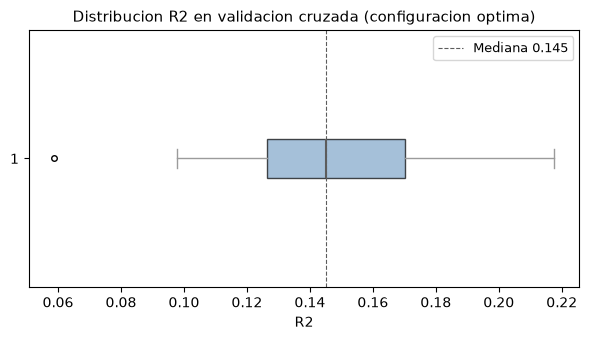

In [5]:
print('Validacion cruzada repetida (15 evaluaciones sobre X_train)...\n')

cv_splitter  = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
r2_scores_cv = []

for fold, (train_idx, val_idx) in enumerate(cv_splitter.split(X_train)):
    _, r2 = entrenar_mlp_custom(
        X_train.iloc[train_idx], y_train.iloc[train_idx],
        X_train.iloc[val_idx],   y_train.iloc[val_idx],
        MLP_CONFIG['hidden'],    MLP_CONFIG['dropout'],
        MLP_CONFIG['lr'],        MLP_CONFIG['epochs'],
        MLP_CONFIG['batch'],     MLP_CONFIG['lambda_corr']
    )
    r2_scores_cv.append(r2)
    if (fold + 1) % 5 == 0:
        print(f'  Pliegues completados: {fold+1}/15  |  R2 medio hasta ahora: {np.mean(r2_scores_cv):.4f}')

print(f'\n  R2 medio CV : {np.mean(r2_scores_cv):.4f}')
print(f'  Desviacion  : {np.std(r2_scores_cv):.4f}')
print(f'  Minimo      : {np.min(r2_scores_cv):.4f}')
print(f'  Maximo      : {np.max(r2_scores_cv):.4f}')

# Grafico: distribucion R2 CV (boxplot) 
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.boxplot(r2_scores_cv, vert=False, patch_artist=True,
           boxprops=dict(facecolor=PALETTE['blue'], alpha=0.7),
           medianprops=dict(color=PALETTE['gray_dark'], linewidth=1.5),
           whiskerprops=dict(color=PALETTE['gray']),
           capprops=dict(color=PALETTE['gray']),
           flierprops=dict(marker='o', color=PALETTE['gray'], markersize=4))
ax.set_xlabel('R2')
ax.set_title('Distribucion R2 en validacion cruzada (configuracion optima)', fontsize=11)
ax.axvline(np.median(r2_scores_cv), color=PALETTE['gray_dark'], linestyle='--', linewidth=0.8, label=f'Mediana {np.median(r2_scores_cv):.3f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 5.- Importancia de variables

Se usa **permutation importance** sobre `X_train` mediante un wrapper sklearn. 

Al igual que en el MLP estándar, la importancia es global sobre los 21 targets.

Adicionalmente se muestra la matriz de correlación aprendida por el modelo comparada con la matriz de correlación real de los datos de entrenamiento, para verificar que la pérdida personalizada esta funcionando.

Entrenando modelo de referencia para analisis...



Top 10 variables más revelantes por permutación:
soil_ph_z                0.0878
gee_temp_media_C_z       0.0594
dem_elevacion_m_z        0.0587
eu_p_z                   0.0519
bulk_density_z           0.0402
gee_ndvi_verano_z        0.0395
eu_ph_z                  0.0369
gee_humedad_rel_pct_z    0.0363
clay_content_z           0.0361
p_z                      0.0343

Diferencia media entre matrices de correlación (real vs predicha): 0.0871
(Valor cercano a 0 indica que la pérdida personalizada está preservando las correlaciones.)


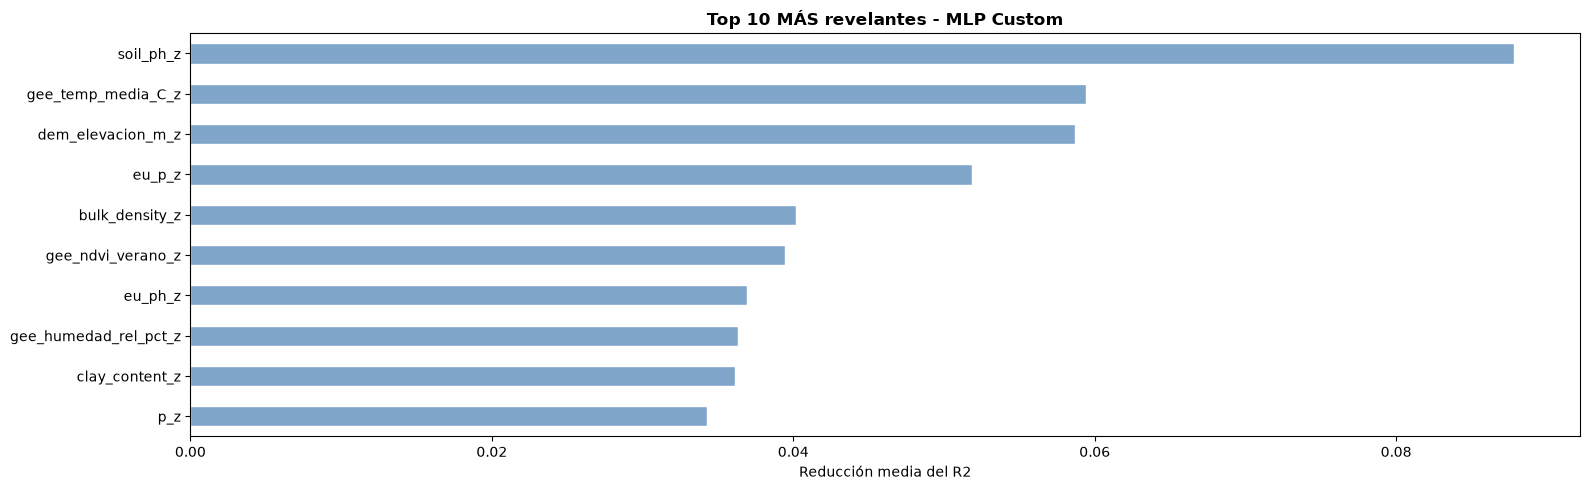

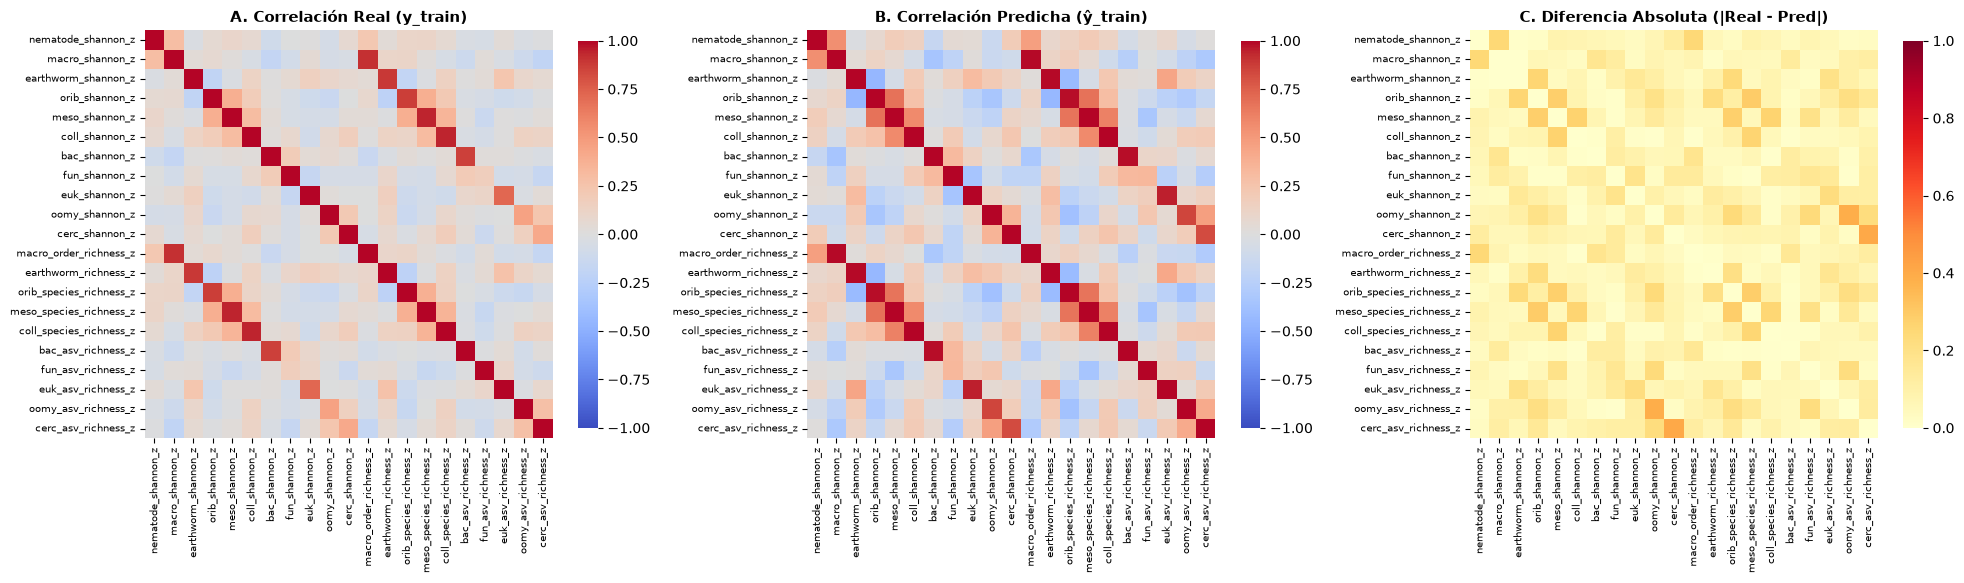

In [6]:
print('Entrenando modelo de referencia para analisis...\n')

# 1. Entrenamiento del modelo con pérdida personalizada
modelo_ref, _ = entrenar_mlp_custom(
    X_train, y_train, X_test, y_test,
    MLP_CONFIG['hidden'], MLP_CONFIG['dropout'],
    MLP_CONFIG['lr'],     MLP_CONFIG['epochs'],
    MLP_CONFIG['batch'],  MLP_CONFIG['lambda_corr']
)

# 2. Wrapper para compatibilidad con Scikit-Learn
class MLPWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model
    def fit(self, X, y): return self
    def predict(self, X):
        X_t = torch.tensor(np.array(X), dtype=torch.float32).to(DEVICE)
        self.model.eval()
        with torch.no_grad():
            return self.model(X_t).cpu().numpy()

wrapper = MLPWrapper(modelo_ref)

# 3. Cálculo de importancia por permutación
perm = permutation_importance(wrapper, X_train, y_train, n_repeats=10, random_state=RANDOM_STATE)
importancias = pd.Series(perm.importances_mean, index=FEATURES_AUTORIZADAS)

top10_imp = importancias.nlargest(10)
bottom10_imp = importancias.nsmallest(10)

print('Top 10 variables más revelantes por permutación:')
print(top10_imp.round(4).to_string())


# 4. Comparación de matrices de correlación (Real vs Predicha)
y_pred_train = wrapper.predict(X_train)
corr_real  = pd.DataFrame(y_train.values, columns=TARGETS).corr()
corr_pred  = pd.DataFrame(y_pred_train,   columns=TARGETS).corr()
diff_corr  = (corr_real - corr_pred).abs()

print(f'\nDiferencia media entre matrices de correlación (real vs predicha): {diff_corr.values.mean():.4f}')
print('(Valor cercano a 0 indica que la pérdida personalizada está preservando las correlaciones.)')

# GRÁFICA 1: Comparativa de Importancia de Variables (Más vs Menos revelantes)

fig, axes = plt.subplots(1, 1, figsize=(16, 5))

# Subplot A: Más revelantes
top10_imp.sort_values().plot(kind='barh', ax=axes, color=PALETTE.get('blue', '#2b5c8f'), edgecolor='white')
axes.set_title('Top 10 MÁS revelantes - MLP Custom', fontsize=12, fontweight='bold')
axes.set_xlabel('Reducción media del R2')
axes.set_ylabel('')

plt.tight_layout()
plt.show()


# GRÁFICA 2: Heatmaps de Preservación de Correlación entre Targets

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Heatmap Real
sns.heatmap(corr_real, ax=axes[0], cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={'shrink': 0.8}, square=True)
axes[0].set_title('A. Correlación Real (y_train)', fontsize=11, fontweight='bold')

# Heatmap Predicha
sns.heatmap(corr_pred, ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={'shrink': 0.8}, square=True)
axes[1].set_title('B. Correlación Predicha (ŷ_train)', fontsize=11, fontweight='bold')

# Heatmap Diferencia
sns.heatmap(diff_corr, ax=axes[2], cmap='YlOrRd', vmin=0, vmax=1, cbar_kws={'shrink': 0.8}, square=True)
axes[2].set_title('C. Diferencia Absoluta (|Real - Pred|)', fontsize=11, fontweight='bold')

for ax in axes:
    ax.tick_params(axis='x', labelsize=7, labelrotation=90)
    ax.tick_params(axis='y', labelsize=7, labelrotation=0)

plt.tight_layout()
plt.show()

## 6.- Entrenamiento

Se entrena un ensamble de 5 redes con semillas distintas usando la perdida personalizada. 

Los pesos se guardan como `.pt` y la configuracion de arquitectura como `.pkl`.

In [7]:
print('Entrenamiento de produccion (ensamble de 5 redes con perdida personalizada)...')
print('-' * 70)

global_start = time.time()
NUM_REDES    = 5

for seed_id in range(NUM_REDES):
    t0 = time.time()
    torch.manual_seed(42 + seed_id)
    np.random.seed(42 + seed_id)

    model, r2_test = entrenar_mlp_custom(
        X_train, y_train, X_test, y_test,
        MLP_CONFIG['hidden'], MLP_CONFIG['dropout'],
        MLP_CONFIG['lr'],     MLP_CONFIG['epochs'],
        MLP_CONFIG['batch'],  MLP_CONFIG['lambda_corr']
    )
    ruta = os.path.join(MODELS_DIR, f'mlp_custom_{seed_id}.pt')
    torch.save(model.state_dict(), ruta)
    print(f'  Red {seed_id+1}/5 | R2 test: {r2_test:.4f} | ({time.time()-t0:.1f}s)')

joblib.dump(MLP_CONFIG, os.path.join(MODELS_DIR, 'mlp_custom_config.pkl'))

print('-' * 70)
print(f'Produccion completada en {(time.time()-global_start)/60:.1f} minutos.')

Entrenamiento de produccion (ensamble de 5 redes con perdida personalizada)...
----------------------------------------------------------------------


  Red 1/5 | R2 test: 0.1452 | (5.3s)


  Red 2/5 | R2 test: 0.1379 | (5.4s)


  Red 3/5 | R2 test: 0.1303 | (5.3s)


  Red 4/5 | R2 test: 0.1339 | (5.4s)


  Red 5/5 | R2 test: 0.1394 | (5.4s)
----------------------------------------------------------------------
Produccion completada en 0.4 minutos.


In [8]:
# PRUEBA 3 - Barrido de random_state (100-5000 en saltos de 10)

RANDOM_STATES = range(100, 5001, 10)
dir_barrido   = os.path.join(MODELS_DIR, 'barrido_rs_mlp_custom')
os.makedirs(dir_barrido, exist_ok=True)

resultados_rs = []
t_inicio = time.time()

for rs in RANDOM_STATES:
    t0 = time.time()
    torch.manual_seed(rs)
    np.random.seed(rs)

    model, _ = entrenar_mlp_custom(
        X_train, y_train, X_test, y_test,
        MLP_CONFIG['hidden'], MLP_CONFIG['dropout'],
        MLP_CONFIG['lr'], MLP_CONFIG['epochs'], MLP_CONFIG['batch'],
        MLP_CONFIG['lambda_corr']
    )

    model.eval()
    with torch.no_grad():
        X_eval_t    = torch.tensor(X_eval.values, dtype=torch.float32).to(DEVICE)
        y_pred_eval = model(X_eval_t).cpu().numpy()
    y_true_eval = y_eval.values

    fila = {
        'random_state': rs,
        'r2_global':   r2_score(y_true_eval, y_pred_eval, multioutput='uniform_average'),
        'rmse_global': np.sqrt(mean_squared_error(y_true_eval, y_pred_eval, multioutput='uniform_average')),
        'mae_global':  mean_absolute_error(y_true_eval, y_pred_eval, multioutput='uniform_average'),
    }
    for t, r2_t in zip(TARGETS, r2_score(y_true_eval, y_pred_eval, multioutput='raw_values')):
        fila[f'{t}_r2'] = r2_t

    torch.save(model.state_dict(), os.path.join(dir_barrido, f'mlp_custom_prod_rs{rs}.pt'))
    resultados_rs.append(fila)
    if rs % 10 == 0:
        print(f'  rs={rs:3d} completado ({time.time()-t0:.1f}s)')

df_barrido_mlp_custom = pd.DataFrame(resultados_rs)
df_barrido_mlp_custom.to_csv(os.path.join(dir_barrido, 'mlp_custom_barrido_rs.csv'), index=False)
print(f'\nBarrido completado en {(time.time()-t_inicio)/60:.1f} minutos.')

  rs=100 completado (4.7s)


  rs=110 completado (4.2s)


  rs=120 completado (4.6s)


  rs=130 completado (4.2s)


  rs=140 completado (4.4s)


...

  rs=4960 completado (4.9s)


  rs=4970 completado (4.4s)


  rs=4980 completado (4.2s)


  rs=4990 completado (4.4s)


  rs=5000 completado (4.5s)

Barrido completado en 40.5 minutos.


## 7.- Evaluación final sobre eval.csv

Se usa `eval.csv` por primera vez para obtener una estimación real del rendimiento en producción. 
A continuación se ejecuta un smoke test para verificar que el pipeline de carga e inferencia funciona correctamente.

**Nota: Interpretacion del indice Shannon H':**

El modelo predice el índice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica).

Evaluacion final sobre eval.csv
------------------------------------------------------------
  R2   global: -0.0370
  RMSE global: 0.9573 puntos de Shannon H'
  MAE  global: 0.7093 puntos de Shannon H'

  Diferencia media de correlacion en eval.csv: 0.1587

  R2 por target:
    nematode_shannon_z             0.0709
    macro_shannon_z                0.2460
    earthworm_shannon_z            0.3929
    orib_shannon_z                 0.2177
    meso_shannon_z                 -0.3216
    coll_shannon_z                 -0.9037
    bac_shannon_z                  -0.0527
    fun_shannon_z                  -0.0767
    euk_shannon_z                  0.1144
    oomy_shannon_z                 0.0626
    cerc_shannon_z                 -0.1118
    macro_order_richness_z         0.3302
    earthworm_richness_z           0.4990
    orib_species_richness_z        0.2486
    meso_species_richness_z        -0.1535
    coll_species_richness_z        -1.5288
    bac_asv_richness_z             -0.0973
   

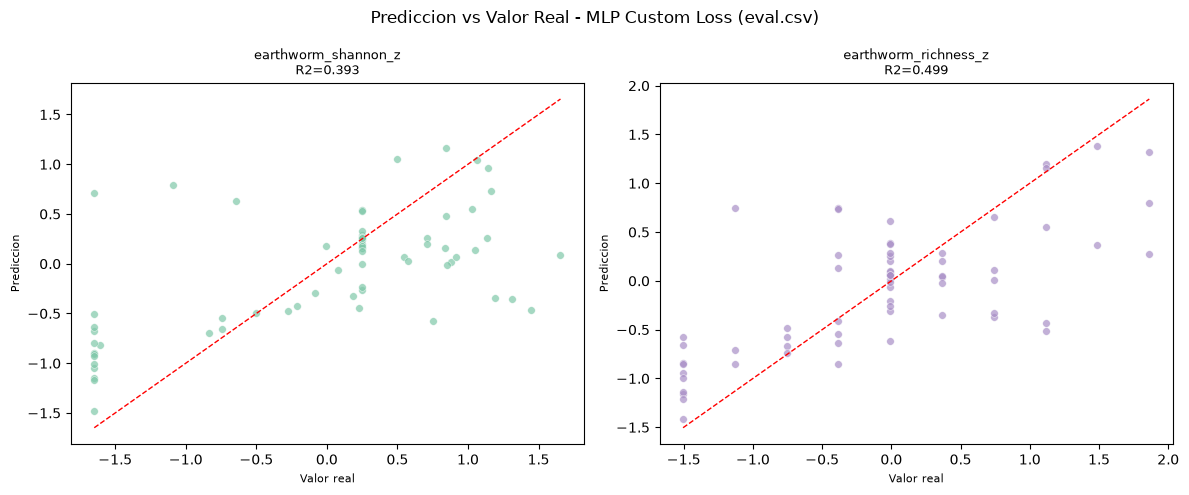

In [9]:
NUM_REDES = 5


# Evaluacion final

print('Evaluacion final sobre eval.csv')
print('-' * 60)

cfg_prod   = joblib.load(os.path.join(MODELS_DIR, 'mlp_custom_config.pkl'))
preds_eval = []

for seed_id in range(NUM_REDES):
    model = MLPMultiSalida(
        len(FEATURES_AUTORIZADAS), len(TARGETS),
        cfg_prod['hidden'], cfg_prod['dropout']
    ).to(DEVICE)
    model.load_state_dict(torch.load(
        os.path.join(MODELS_DIR, f'mlp_custom_{seed_id}.pt'), map_location=DEVICE
    ))
    model.eval()
    with torch.no_grad():
        X_eval_t = torch.tensor(X_eval.values, dtype=torch.float32).to(DEVICE)
        preds_eval.append(model(X_eval_t).cpu().numpy())

y_pred_eval = np.mean(preds_eval, axis=0)
y_true_eval = y_eval.values

r2_global   = r2_score(y_true_eval, y_pred_eval, multioutput='uniform_average')
rmse_global = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval, multioutput='uniform_average'))
mae_global  = mean_absolute_error(y_true_eval, y_pred_eval, multioutput='uniform_average')

print(f'  R2   global: {r2_global:.4f}')
print(f'  RMSE global: {rmse_global:.4f} puntos de Shannon H\'')
print(f'  MAE  global: {mae_global:.4f} puntos de Shannon H\'')

# Verificacion de correlaciones sobre eval.csv
corr_real_eval = pd.DataFrame(y_true_eval, columns=TARGETS).corr()
corr_pred_eval = pd.DataFrame(y_pred_eval, columns=TARGETS).corr()
diff_eval      = (corr_real_eval - corr_pred_eval).abs().values.mean()
print(f'\n  Diferencia media de correlacion en eval.csv: {diff_eval:.4f}')

print('\n  R2 por target:')
for t, r2 in zip(TARGETS, r2_score(y_true_eval, y_pred_eval, multioutput='raw_values')):
    print(f'    {t:30} {r2:.4f}')


# Smoke test

print('\nSmoke test - Inferencia con datos reales')
print('-' * 60)

try:
    df_new_data      = X_eval.sample(n=3, random_state=RANDOM_STATE)
    indices_elegidos = df_new_data.index

    votos = []
    for seed_id in range(NUM_REDES):
        model = MLPMultiSalida(
            len(FEATURES_AUTORIZADAS), len(TARGETS),
            cfg_prod['hidden'], cfg_prod['dropout']
        ).to(DEVICE)
        model.load_state_dict(torch.load(
            os.path.join(MODELS_DIR, f'mlp_custom_{seed_id}.pt'), map_location=DEVICE
        ))
        model.eval()
        with torch.no_grad():
            X_new_t = torch.tensor(df_new_data.values, dtype=torch.float32).to(DEVICE)
            pred    = model(X_new_t).cpu().numpy()
        votos.append(pred)
        idx_e = TARGETS.index('earthworm_shannon_z')
        print(f'  Red {seed_id+1} | '
              f'Fila {indices_elegidos[0]}: {pred[0, idx_e]:.4f} | '
              f'Fila {indices_elegidos[1]}: {pred[1, idx_e]:.4f} | '
              f'Fila {indices_elegidos[2]}: {pred[2, idx_e]:.4f}  (earthworm_shannon_z)')

    consenso = np.mean(votos, axis=0)
    idx_earth = TARGETS.index('earthworm_shannon_z')

    print('-' * 60)
    print('  Resultados detallados por muestra (earthworm_shannon_z):')
    print('-' * 60)

    for i, idx in enumerate(indices_elegidos):
        pred_val = consenso[i, idx_earth]
        real_val = y_eval.loc[idx, 'earthworm_shannon_z']
        error    = abs(pred_val - real_val)
        print(f'    Fila {idx:<4} | Prediccion: {pred_val:.4f} | '
              f'Valor Real: {real_val:.4f} | Error absoluto: {error:.4f}')

    print('-' * 60)
    print('\nSmoke test superado. El pipeline MLP con perdida personalizada funciona correctamente.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')


# Grafico: scatter prediccion vs valor real (targets principales)
_targets_plot = ['earthworm_shannon_z', 'earthworm_richness_z']
_colors_plot  = [PALETTE['green'], PALETTE['purple']]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt, col in zip(axes, _targets_plot, _colors_plot):
    idx_col = TARGETS.index(tgt)
    yp = y_pred_eval[:, idx_col]
    yt = y_true_eval[:, idx_col]
    ax.scatter(yt, yp, alpha=0.7, s=30, color=col, edgecolors='white', linewidths=0.4)
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
plt.suptitle('Prediccion vs Valor Real - MLP Custom Loss (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()